In [2]:
path

'/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes'

# Importing Libraries

In [1]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


In [2]:
!pip install pytorch-lightning

In [3]:
from rich import print
from rich.console import Console
from rich.table import Table


import json
from collections import Counter

from pathlib import Path
import numpy as np

import shutil
import cv2
import random
import matplotlib.pyplot as plt

In [4]:


from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

import torch
import torch.nn as nn
import pytorch_lightning as pl
import segmentation_models_pytorch as smp
from pytorch_lightning import Trainer

In [7]:
# from transformers import (
#     SegformerForSemanticSegmentation,
#     SegformerImageProcessor,
# )
# from pytorch_lightning import Trainer
# from pytorch_lightning.callbacks import (
#     EarlyStopping,
#     ModelCheckpoint,
#     LearningRateMonitor,
# )
# from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR


# Data Understanding

In [5]:
images_path = f"/kaggle/input/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes/data/images"

labels_path=f"/kaggle/input/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes/data/labels"

annotation_json_path=f"/kaggle/input/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes/data/annotations_coco.json"

output_path="masked_images"

output_split_path="Split_Data"

In [6]:
labels_txt_files = list(Path(labels_path).glob("*.txt"))
print("Txt Files:",len(labels_txt_files))

Txt Files: 2009

In [7]:
def load_json_file(json_path):
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
        return data
        print("[green]✔ JSON loaded successfully[/green]")
    except Exception as e:
        print(f"[red]✘ Invalid JSON: {e}[/red]")
        return
data=load_json_file(annotation_json_path)

In [8]:

print("[bold cyan]Dataset Summary[/bold cyan]")
print(f"Images: {len(data['images'])}")
print(f"Annotations: {len(data['annotations'])}")
print(f"Categories: {len(data['categories'])}\n")



Dataset Summary

Images: 2009

Annotations: 4737

Categories: 3

In [9]:
console = Console()
table = Table(title="Categories")
table.add_column("ID", justify="right")
table.add_column("Name", justify="left")

for cat in data["categories"]:
    table.add_row(str(cat["id"]), cat["name"])

console.print(table)

   Categories   
┏━━━━┳━━━━━━━━━┓
┃ ID ┃ Name    ┃
┡━━━━╇━━━━━━━━━┩
│  0 │ pothole │
│  1 │ crack   │
│  2 │ manhole │
└────┴─────────┘

In [10]:
print("[bold yellow]Checking Annotations...[/bold yellow]")
for ann in data["annotations"][:5]:
    if not all(k in ann for k in ["id", "image_id", "category_id"]):
        print(f"[red]✘ Invalid annotation: {ann}[/red]")
        break
    if "bbox" in ann and len(ann["bbox"]) != 4:
        print(f"[red]✘ Invalid bbox: {ann['bbox']}[/red]")
        break

print("[green]✔ Annotation structure looks OK[/green]\n")


print("[bold magenta]Sample Annotation[/bold magenta]")
print(data["annotations"][0])





Checking Annotations...

✔ Annotation structure looks OK

Sample Annotation

{
    'id': 1,
    'image_id': 1,
    'category_id': 2,
    'bbox': [203.00032000000002, 173.00016, 190.99967999999998, 51.999840000000006],
    'area': 9931.9528000512,
    'iscrowd': 0
}

## 1.1 Class Distribution Over Data

In [11]:
def show_category_distribution(data):
    cat_map = {cat["id"]: cat["name"] for cat in data["categories"]}
    counts = Counter([ann["category_id"] for ann in data["annotations"]])

    table = Table(title="Category Distribution")
    table.add_column("Category ID", justify="right")
    table.add_column("Category Name", justify="left")
    table.add_column("Count", justify="right")

    total = sum(counts.values())

    for cat_id, count in counts.items():
        table.add_row(str(cat_id), cat_map.get(cat_id, "Unknown"), str(count))

    print(table)


    print(f"\n[bold cyan]Total annotations:[/bold cyan] {total}")
    print("[bold cyan]Class imbalance check:[/bold cyan]")

    for cat_id, count in counts.items():
        perc = (count / total) * 100
        print(f"{cat_map[cat_id]} → {perc:.2f}%")

show_category_distribution(data)

         Category Distribution         
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Category ID ┃ Category Name ┃ Count ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━┩
│           2 │ manhole       │   957 │
│           0 │ pothole       │  1261 │
│           1 │ crack         │  2519 │
└─────────────┴───────────────┴───────┘

Total annotations: 4737

Class imbalance check:

manhole → 20.20%

pothole → 26.62%

crack → 53.18%

In [12]:
counts = Counter([ann["image_id"] for ann in data["annotations"]])

print("Max objects in one image:", max(counts.values()))
print("Min objects in one image:", min(counts.values()))

Max objects in one image: 13

Min objects in one image: 1

- In json file bbox only  given which we can not use for unet segmentation task.
- but we can use labels/txt files to make segmentation mask because in it polygon format bbox given.

In [13]:
class_distribution={}
for file in labels_txt_files:
   with file.open("r") as f:
        for line in f:
            class_id=int(line.strip()[0])
            class_distribution[class_id]=class_distribution.get(class_id,0)+1
            # print((line.strip()))

In [14]:
print("class_distribution_train:",class_distribution)

class_distribution_train:
{2: 957, 1: 2519, 0: 1261}

# Step 1: COCO conversion script to turn annotations_coco.json into pixel mask PNG files

In [57]:
def yolo_seg_to_mask(labels_txt_files, images_dir, output_dir):
    Path(output_dir).mkdir(exist_ok=True)

    for label_file in labels_txt_files:
        image_file = Path(images_dir) / (label_file.stem + ".jpg")

        img = cv2.imread(str(image_file))
        h, w = img.shape[:2]

        mask = np.zeros((h, w), dtype=np.uint8)

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            # 2 0.317188 0.480556 0.615625 0.480556 0.615625 0.625000 0.317188 0.625000
            # values= [2.0,0.317188,0.480556,...,0.625000]

            values = list(map(float, line.strip().split()))

            cls = int(values[0])
            coords = values[1:]

            # Convert normalized → pixel
            pts = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * w)
                y = int(coords[i+1] * h)
                pts.append([x, y])

            pts = np.array(pts, dtype=np.int32)

            # Fill polygon
            cv2.fillPoly(mask, [pts], cls+1)


        out_path = Path(output_dir) / (label_file.stem + ".png")
        cv2.imwrite(str(out_path), mask)

    print("✔ Masks generated from YOLO segmentation labels")

In [58]:
yolo_seg_to_mask(labels_txt_files,images_path,output_path)

✔ Masks generated from YOLO segmentation labels

In [59]:
output_img_files = list(Path(output_path).glob("*.png"))
print("Masked Image Files:",len(output_img_files))

Masked Image Files: 2009

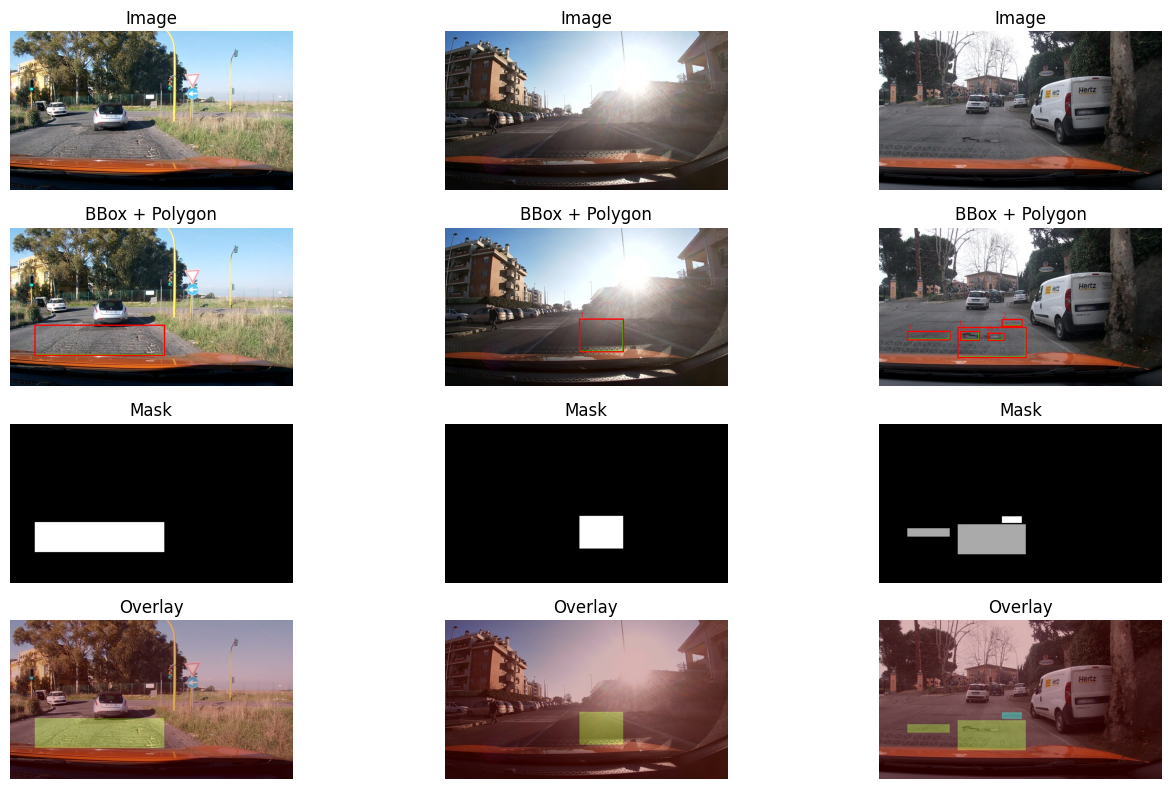

In [60]:
def draw_polygons_and_boxes(img, label_path):
    h, w = img.shape[:2]
    lines = label_path.read_text().splitlines()

    for line in lines:
        values = list(map(float, line.split()))
        cls = int(values[0])
        coords = values[1:]

        pts = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i+1] * h)
            pts.append([x, y])

        pts = np.array(pts, dtype=np.int32)

        cv2.polylines(img, [pts], True, (0, 255, 0), 2)

        x, y, bw, bh = cv2.boundingRect(pts)
        cv2.rectangle(img, (x, y), (x+bw, y+bh), (255, 0, 0), 2)

        cv2.putText(img, f"{cls}", (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    return img

def overlay_mask(img, mask):
    colored = cv2.applyColorMap((mask * 50).astype(np.uint8), cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 0.7, colored, 0.3, 0)


def show_random_with_saved_masks(images_dir, labels_dir, masks_dir, num_samples=3):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)
    masks_dir = Path(masks_dir)

    image_files = list(images_dir.glob("*.*"))
    selected = random.sample(image_files, min(num_samples, len(image_files)))

    plt.figure(figsize=(14, 8))

    for i, img_path in enumerate(selected):
        label_path = labels_dir / (img_path.stem + ".txt")
        mask_path = masks_dir / (img_path.stem + ".png")

        if not label_path.exists() or not mask_path.exists():
            continue

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        img_boxes = draw_polygons_and_boxes(img.copy(), label_path)

        overlay = overlay_mask(img, mask)


        plt.subplot(4, len(selected), i+1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(4, len(selected), i+1+len(selected))
        plt.imshow(img_boxes)
        plt.title("BBox + Polygon")
        plt.axis("off")

        plt.subplot(4, len(selected), i+1+2*len(selected))
        plt.imshow(mask, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

        plt.subplot(4, len(selected), i+1+3*len(selected))
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_random_with_saved_masks(images_path, labels_path, output_path, 3)

# 2. Split the Data Into train,test,val

In [61]:
def split_dataset(images_dir, labels_dir, masks_dir, output_dir,
                  train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):

    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)
    masks_dir = Path(masks_dir)
    output_dir = Path(output_dir)

    for split in ["train", "val", "test"]:
        (output_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (output_dir / split / "labels").mkdir(parents=True, exist_ok=True)
        (output_dir / split / "masks").mkdir(parents=True, exist_ok=True)


    image_files = list(images_dir.glob("*.*"))
    random.shuffle(image_files)

    total = len(image_files)

    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    splits = {
        "train": image_files[:train_end],
        "val": image_files[train_end:val_end],
        "test": image_files[val_end:]
    }

    for split, files in splits.items():
        print(f"\n📂 {split}: {len(files)} samples")

        for img_path in files:
            stem = img_path.stem

            label_path = labels_dir / f"{stem}.txt"
            mask_path = masks_dir / f"{stem}.png"


            if not label_path.exists() or not mask_path.exists():
                continue

            shutil.copy(img_path, output_dir / split / "images" / img_path.name)
            shutil.copy(label_path, output_dir / split / "labels" / label_path.name)
            shutil.copy(mask_path, output_dir / split / "masks" / mask_path.name)

    print("\n✔ Dataset split completed")


In [62]:
split_dataset(
    images_path,
    labels_path,
    output_path,
    output_split_path
)

📂 train: 1406 samples

📂 val: 401 samples

📂 test: 202 samples

✔ Dataset split completed

## 2.1 Distribution Of Labels

In [54]:
def get_class_distribution_labels(labels_dir):
    labels_dir = Path(labels_dir)

    counter = Counter()

    for file in labels_dir.glob("*.txt"):
        lines = file.read_text().splitlines()

        for line in lines:
            cls = int(line.split()[0])
            counter[cls] += 1

    return counter



def print_distribution(counter, split_name):
    total = sum(counter.values())

    print(f"\n📊 {split_name} Distribution")
    print("-" * 30)

    for cls, count in sorted(counter.items()):
        perc = (count / total) * 100
        print(f"Class {cls}: {count} ({perc:.2f}%)")

    print(f"Total objects: {total}")



train_dist = get_class_distribution_labels(f"{output_split_path}/train/labels")
val_dist   = get_class_distribution_labels(f"{output_split_path}/val/labels")
test_dist  = get_class_distribution_labels(f"{output_split_path}/test/labels")

print_distribution(train_dist, "Train")
print_distribution(val_dist, "Validation")
print_distribution(test_dist, "Test")

📊 Train Distribution

------------------------------

Class 0: 1157 (26.65%)

Class 1: 2316 (53.35%)

Class 2: 868 (20.00%)

...

------------------------------

Class 0: 237 (26.90%)

Class 1: 455 (51.65%)

Class 2: 189 (21.45%)

Total objects: 881

## 2.2 Distribution Of Masks

In [55]:
def get_class_distribution_masks(masks_dir):
    masks_dir = Path(masks_dir)

    counter = Counter()

    for file in masks_dir.glob("*.png"):
        mask = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)

        unique, counts = np.unique(mask, return_counts=True)

        for u, c in zip(unique, counts):
            counter[int(u)] += int(c)

    return counter


train_mask_dist = get_class_distribution_masks(f"{output_split_path}/train/masks")
val_mask_dist   = get_class_distribution_masks(f"{output_split_path}/val/masks")
test_mask_dist  = get_class_distribution_masks(f"{output_split_path}/test/masks")

print_distribution(train_mask_dist, "Train (Mask Pixels)")
print_distribution(val_mask_dist, "Validation (Mask Pixels)")
print_distribution(test_mask_dist, "Test (Mask Pixels)")

📊 Train (Mask Pixels) Distribution

------------------------------

Class 0: 406110343 (95.80%)

Class 1: 12657178 (2.99%)

Class 2: 4911546 (1.16%)

...

Class 0: 84447786 (95.70%)

Class 1: 1836522 (2.08%)

Class 2: 1820278 (2.06%)

Class 3: 138614 (0.16%)

Total objects: 88243200

# STEP 3: Define transforms Resize all images to 512×512 and normalize

In [56]:
train_transforms = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

val_transforms = A.Compose([
    A.Resize(512, 512),
])

# STEP 4:  Build the dataset class

In [24]:
NUM_CLASSES  = 4
MAX_EPOCHS   = 20
WARMUP_EPOCHS = 5
IMG_SIZE     = 512
PIXEL_COUNTS = [308_975_644, 1_407_607, 12_663_129, 896_020]

In [25]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

In [26]:
processor = SegformerImageProcessor(
    do_resize=True,
    size={"height": IMG_SIZE, "width": IMG_SIZE},
    do_normalize=True,                         # ImageNet mean/std
)


model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b1-finetuned-ade-512-512",
    num_labels=4,
    ignore_mismatched_sizes=True
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/54.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b1-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([4])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/54.9M [00:00<?, ?B/s]

In [27]:
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.transform = transform

        self.image_paths = sorted(self.images_dir.glob("*.*"))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.masks_dir / (img_path.stem + ".png")

        if not mask_path.exists():
            raise FileNotFoundError(f"{mask_path} not found")

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # ---- SegFormer processing ----
        encoded = processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )

        return {
            "pixel_values": encoded["pixel_values"].squeeze(),  # (3, H, W)
            "labels": encoded["labels"].squeeze()               # (H, W)
        }

In [28]:
train_dataset = SegmentationDataset(
    images_dir=f"{output_split_path}/train/images",
    masks_dir=f"{output_split_path}/train/masks",
    transform=train_transforms
)

val_dataset = SegmentationDataset(
    images_dir=f"{output_split_path}/val/images",
    masks_dir=f"{output_split_path}/val/masks",
    transform=val_transforms
)

In [29]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [33]:
# 0 → background
# 1,2,3 → classes
# Classes Because -> cls+1

In [30]:
sample = train_dataset[0]

img = sample["pixel_values"]
mask = sample["labels"]

print(img.shape)   # (3, 512, 512)
print(mask.shape)  # (512, 512)

torch.Size([3, 512, 512])

torch.Size([512, 512])

# 6. Define the model

In [31]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

In [36]:
#  Backbone = ResNet-34

# Extracts features from image
# Strong + lightweight
# Good default choice


# Pretrained on ImageNet

# Faster convergence
# Better performance
# Especially useful for small datasets

# in_channels=3
# RGB image → 3 channels

# 4. classes=4
# 0 → background
# 1 → pothole
# 2 → crack
# 3 → manhole

# For input:
# ( B, 3, 512, 512 )
# Output:
# ( B, 4, 512, 512 )

# STEP 7. Set the loss function CrossEntropyLoss with class weights. .

In [37]:
weights = torch.tensor([0.2, 1.0, 3.0, 1.0])
criterion = nn.CrossEntropyLoss(weight=weights)


# STEP 8: Train Model Pass Everything To Lightning

### SIMPLE WEIGHTS AND WITHOUT DICE LOSS

In [38]:
# def compute_iou(preds, masks, num_classes=4):
#         preds = torch.argmax(preds, dim=1)

#         ious = []

#         for cls in range(num_classes):
#             pred_cls = (preds == cls)
#             mask_cls = (masks == cls)

#             intersection = (pred_cls & mask_cls).float().sum()
#             union = (pred_cls | mask_cls).float().sum()

#             if union == 0:
#                 continue

#             ious.append((intersection / (union + 1e-6)).item())

#         return sum(ious) / len(ious)

# class UNetLightning(pl.LightningModule):
#     def __init__(self, lr=1e-3):
#         super().__init__()

#         # Model
#         self.model = smp.Unet(
#             encoder_name="resnet34",
#             encoder_weights="imagenet",
#             in_channels=3,
#             classes=4
#         )

#         weights = torch.tensor([0.2, 1.0, 3.0, 1.0])
#         self.criterion = nn.CrossEntropyLoss(weight=weights)

#         self.lr = lr

#     def forward(self, x):
#         return self.model(x)

#     def training_step(self, batch, batch_idx):
#         images, masks = batch

#         preds = self(images)
#         loss = self.criterion(preds, masks)

#         self.log("train_loss", loss, prog_bar=True)
#         return loss

#     def validation_step(self, batch, batch_idx):
#         images, masks = batch

#         preds = self(images)
#         loss = self.criterion(preds, masks)

#         iou = compute_iou(preds, masks)

#         self.log("val_loss", loss, prog_bar=True)
#         self.log("val_iou", iou, prog_bar=True)

#     def configure_optimizers(self):
#         return torch.optim.Adam(self.parameters(), lr=self.lr)



### USING DICE LOSS

In [32]:
def compute_iou(preds, masks, num_classes=NUM_CLASSES, ignore_index=0):
    """Mean IoU over foreground classes only."""
    ious = []
    for cls in range(num_classes):
        if cls == ignore_index:
            continue
        pred_c = (preds == cls)
        true_c = (masks == cls)
        intersection = (pred_c & true_c).float().sum()
        union        = (pred_c | true_c).float().sum()
        if union == 0:
            continue
        ious.append((intersection / (union + 1e-6)).item())
    return sum(ious) / len(ious) if ious else 0.0

In [33]:
import torch.nn.functional as F
class SegFormerLightning(pl.LightningModule):
    def __init__(self, lr=5e-5):
        super().__init__()
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/segformer-b1-finetuned-ade-512-512",
            num_labels=4,
            ignore_mismatched_sizes=True
        )
        # ---- SAME class weights (keep your logic) ----
        total = 308975644 + 1407607 + 12663129 + 896020
        weights = torch.tensor([
            total / (4 * 308975644),
            total / (4 * 1407607),
            total / (4 * 12663129),
            total / (4 * 896020)
        ])
        self.ce_loss = nn.CrossEntropyLoss(weight=weights)
        self.lr = lr
    def forward(self, pixel_values):
        return self.model(pixel_values=pixel_values)
    # ---- custom dice (because smp DiceLoss won't work directly here) ----
    def dice_loss(self, logits, targets, eps=1e-6):
        preds = torch.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=4).permute(0, 3, 1, 2).float()
        intersection = (preds * targets_one_hot).sum(dim=(2, 3))
        union = preds.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))
        dice = (2 * intersection + eps) / (union + eps)
        return 1 - dice.mean()
    def compute_loss(self, logits, masks):
        ce = self.ce_loss(logits, masks)
        dice = self.dice_loss(logits, masks)
        return 0.5 * ce + 0.5 * dice
    def training_step(self, batch, batch_idx):
        pixel_values = batch["pixel_values"]
        masks = batch["labels"]
        outputs = self.model(pixel_values=pixel_values)
        logits = outputs.logits
        # ---- IMPORTANT: upsample logits ----
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        loss = self.compute_loss(logits, masks)
        self.log("train_loss", loss, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        pixel_values = batch["pixel_values"]
        masks = batch["labels"]
        outputs = self.model(pixel_values=pixel_values)
        logits = outputs.logits
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        loss = self.compute_loss(logits, masks)
        preds = torch.argmax(logits, dim=1)
        iou = compute_iou(preds, masks)
     
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_iou", iou, prog_bar=True)
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", patience=5, factor=0.5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val_iou"}
        }

In [34]:
# callbacks = [
#     ModelCheckpoint(
#         monitor="val_iou",
#         mode="max",
#         save_top_k=3,
#         filename="segformer-{epoch:03d}-iou{val_iou:.4f}",
#         verbose=True,
#     ),
#     ModelCheckpoint(filename="last", save_last=True),
#     EarlyStopping(monitor="val_iou", mode="max", patience=20, verbose=True),
#     LearningRateMonitor(logging_interval="epoch"),
# ]

## TRAIN USING EFFICIENT NET

In [44]:


# class UNetLightning(pl.LightningModule):
#     def __init__(self, lr=1e-3):
#         super().__init__()
#         self.model = smp.Unet(
#             encoder_name="efficientnet-b4",
#             encoder_weights="imagenet",
#             in_channels=3,
#             classes=4
#         )
#         total = 308975644 + 1407607 + 12663129 + 896020
#         weights = torch.tensor([
#             total / (4 * 308975644),
#             total / (4 * 1407607),
#             total / (4 * 12663129),
#             total / (4 * 896020)
#         ])
#         self.ce_loss   = nn.CrossEntropyLoss(weight=weights)
#         self.dice_loss = smp.losses.DiceLoss(mode="multiclass")
#         self.lr = lr

#     def forward(self, x):
#         return self.model(x)


#     def compute_loss(self, preds, masks):
#         return 0.5 * self.ce_loss(preds, masks) + 0.5 * self.dice_loss(preds, masks)

#     def training_step(self, batch, batch_idx):
#         images, masks = batch
#         preds = self(images)
#         loss = self.compute_loss(preds, masks)
#         self.log("train_loss", loss, prog_bar=True)
#         return loss

#     def validation_step(self, batch, batch_idx):
#         images, masks = batch
#         preds = self(images)
#         loss = self.compute_loss(preds, masks)
#         iou = compute_iou(preds, masks)
#         self.log("val_loss", loss, prog_bar=True)
#         self.log("val_iou", iou, prog_bar=True)

#     def configure_optimizers(self):
#         optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
#         scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#             optimizer, mode="max", patience=5, factor=0.5
#         )
#         return {
#             "optimizer": optimizer,
#             "lr_scheduler": {"scheduler": scheduler, "monitor": "val_iou"}
#         }

In [35]:
from pytorch_lightning.loggers import CSVLogger

logger = CSVLogger("segformer_logs_1", name="segformer")

In [36]:
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    monitor="val_iou",
    mode="max",
    save_top_k=1,
    filename="best-model"
)

In [37]:
ckpt_path = "/kaggle/input/models/sanghavijainamp/segmentationsegformer/pytorch/default/1/epoch29-step3450.ckpt"

In [38]:
model = SegFormerLightning()

trainer = Trainer(
    max_epochs=50,
    accelerator="auto",
    devices=1,
    log_every_n_steps=10,
    logger=logger
)

# trainer = Trainer(
#     max_epochs=MAX_EPOCHS,
#     accelerator="auto",
#     devices=1,
#     precision="16-mixed",
#     accumulate_grad_batches=4,
#     gradient_clip_val=1.0,
#     log_every_n_steps=10,
#     callbacks=callbacks,
#     logger=logger,
# )



trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=ckpt_path   # 🔥 this resumes training
)
# trainer.fit(
#     model,
#     train_dataloaders=train_loader,
#     val_dataloaders=val_loader,
#                 # resume from your existing checkpoint
# )


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b1-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([4])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs m

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ SegformerForSemanticSegmentation │ 13.7 M │ eval  │     0 │
│ 1 │ ce_loss │ CrossEntropyLoss                 │      0 │ train │     0 │
└───┴─────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 13.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.7 M                                                                                               
Total estimated model params size (MB): 54                                                                         
Modules in train mode: 1                                                                                           
Modules in eval mode: 213                                                                                          
Total FLOPs: 0

Restored all states from the checkpoint at /kaggle/input/models/sanghavijainamp/segmentationsegformer/pytorch/default/1/epoch29-step3450.ckpt


...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 213 module(s) in eval mode 
at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can 
ignore this warning.

`Trainer.fit` stopped: `max_epochs=50` reached.


In [42]:
import pandas as pd

In [40]:
import os
print(os.listdir("./segformer_logs_1/segformer"))

['version_0']

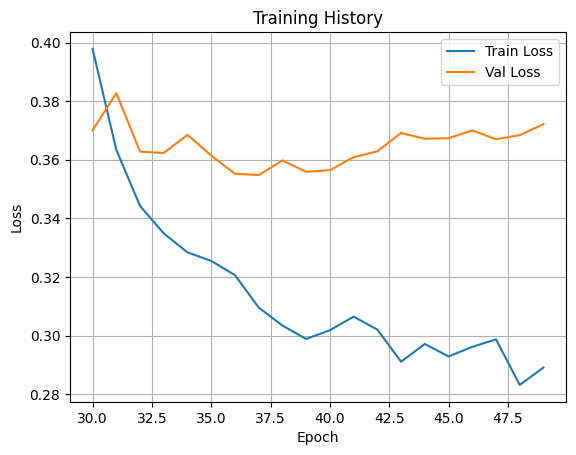

In [43]:
df = pd.read_csv("/kaggle/working/segformer_logs_1/segformer/version_0/metrics.csv")
df = df.groupby("epoch").mean(numeric_only=True)
plt.figure()

plt.plot(df.index, df["train_loss"], label="Train Loss")
plt.plot(df.index, df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid()

plt.show()

In [44]:
df

,step,train_loss,val_iou,val_loss
epoch,,,,
30,3498.777778,0.397830,0.367904,0.370060
31,3583.600000,0.363401,0.407407,0.382725
32,3673.400000,0.344242,0.437127,0.362780
33,3763.200000,0.334858,0.473857,0.362308
34,3853.000000,0.328396,0.479612,0.368519
35,3938.777778,0.325478,0.443934,0.361416
36,4023.600000,0.320625,0.472306,0.355210
37,4113.400000,0.309570,0.497156,0.354788
38,4203.200000,0.303426,0.506760,0.359762


## STEP 9: EVALUATE THE MODEL

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
criterion.weight = criterion.weight.to(device)
model.eval()
print("done",device)

done cuda

In [45]:
def pixel_accuracy(preds, masks):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == masks).float().sum()
    total = torch.numel(masks)

    return (correct / total).item()

In [46]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    total_iou = 0
    total_acc = 0

    device = next(model.parameters()).device

    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device)
            masks = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits

            # 🔥 Upsample to match mask size
            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            # ---- Loss (reuse your class logic if needed) ----
            loss = F.cross_entropy(logits, masks)

            preds = torch.argmax(logits, dim=1)

            iou = compute_iou(preds, masks)
            acc = pixel_accuracy(logits, masks)

            total_loss += loss.item()
            total_iou += iou
            total_acc += acc

    total_loss /= len(loader)
    total_iou /= len(loader)
    total_acc /= len(loader)

    print("\n📊 Evaluation Results")
    print(f"Loss: {total_loss:.4f}")
    print(f"IoU: {total_iou:.4f}")
    print(f"Pixel Accuracy: {total_acc:.4f}")

    return total_loss, total_iou, total_acc

In [47]:
evaluate(model, val_loader)

📊 Evaluation Results

Loss: 0.0831

IoU: 0.5143

Pixel Accuracy: 0.9750

(0.08313623844430997, 0.5143071652796025, 0.9750334482926589)

In [79]:
def visualize_predictions(model, dataset, num_samples=3):
    model.eval()
    device = next(model.parameters()).device

    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(12, 8))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]

            image = sample["pixel_values"]   # (3, H, W)
            mask = sample["labels"]          # (H, W)

            image_tensor = image.unsqueeze(0).to(device)

            outputs = model(pixel_values=image_tensor)
            logits = outputs.logits

            # 🔥 Upsample logits to original size
            logits = F.interpolate(
                logits,
                size=mask.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            pred_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

            # ---- Convert image for display ----
            img = image.permute(1, 2, 0).cpu().numpy()
            gt_mask = mask.cpu().numpy()

            # normalize for visualization (since processor normalized it)
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            def overlay(img, mask):
                colored = cv2.applyColorMap((mask * 50).astype(np.uint8), cv2.COLORMAP_JET)
                return cv2.addWeighted((img * 255).astype(np.uint8), 0.7, colored, 0.3, 0)

            overlay_pred = overlay(img, pred_mask)

            # ---- plotting ----
            plt.subplot(4, num_samples, i+1)
            plt.imshow(img)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(4, num_samples, i+1+num_samples)
            plt.imshow(gt_mask, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(4, num_samples, i+1+2*num_samples)
            plt.imshow(pred_mask, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

            plt.subplot(4, num_samples, i+1+3*num_samples)
            plt.imshow(overlay_pred)
            plt.title("Overlay")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

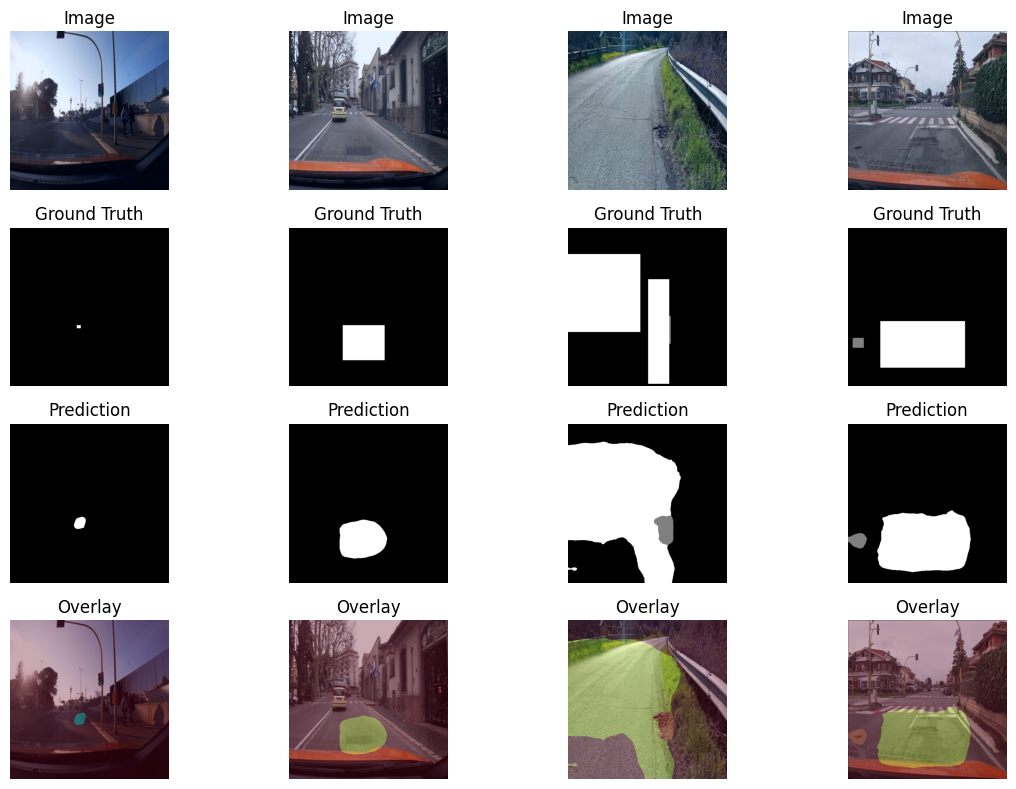

In [80]:
visualize_predictions(model, val_dataset, num_samples=4)

# SAVE THE MODEL

In [81]:

torch.save(model.state_dict(), "unet_model.pth")

In [82]:


def prepare_project_export(
    output_dir="project_export",
    model_path="unet_model.pth",
    logs_dir="logs",
    tb_logs_dir="tb_logs",
    code_dir=".",
    sample_images_dir=None,
    sample_masks_dir=None
):
    output_dir = Path(output_dir)


    (output_dir / "model").mkdir(parents=True, exist_ok=True)
    (output_dir / "logs").mkdir(exist_ok=True)
    (output_dir / "code").mkdir(exist_ok=True)
    (output_dir / "data_sample").mkdir(exist_ok=True)

    if Path(model_path).exists():
        shutil.copy(model_path, output_dir / "model" / "unet_model.pth")

    if Path(logs_dir).exists():
        shutil.copytree(logs_dir, output_dir / "logs", dirs_exist_ok=True)

    if Path(tb_logs_dir).exists():
        shutil.copytree(tb_logs_dir, output_dir / "logs" / "tb_logs", dirs_exist_ok=True)

    for file in Path(code_dir).glob("*"):
        if file.suffix in [".py", ".ipynb"]:
            shutil.copy(file, output_dir / "code" / file.name)

    if sample_images_dir and sample_masks_dir:
        sample_images = list(Path(sample_images_dir).glob("*.*"))[:10]
        sample_masks = list(Path(sample_masks_dir).glob("*.*"))[:10]

        for f in sample_images:
            shutil.copy(f, output_dir / "data_sample" / f.name)

        for f in sample_masks:
            shutil.copy(f, output_dir / "data_sample" / f.name)

    readme = output_dir / "README.txt"
    readme.write_text(
        "U-Net Segmentation Project\n\n"
        "- Model: U-Net (ResNet34 encoder)\n"
        "- Classes: background, pothole, crack, manhole\n"
        "- Framework: PyTorch + Lightning\n"
        "- Includes: model, logs, code, sample data\n"
    )

    print("✔ Project export ready!")

In [84]:
prepare_project_export(
    output_dir="project_export",
    model_path="./unet_model.pth",
    logs_dir="./segformer_logs",
    code_dir=".",
    sample_images_dir="./Split_Data/val/images",
    sample_masks_dir="./Split_Data/val/masks"
)

✔ Project export ready!

In [83]:
import os
print(os.listdir())

['.config', 'segformer_logs', 'unet_model.pth', 'masked_images', 'Split_Data', 'sample_data']

In [85]:
import torch
import cv2
import numpy as np
from pathlib import Path


def save_predictions(model, dataset, output_dir="prediction_outputs", num_samples=10):
    model.eval()
    device = next(model.parameters()).device

    output_dir = Path(f"./project_export/{output_dir}")
    output_dir.mkdir(exist_ok=True)

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    with torch.no_grad():
        for idx in indices:
            image, mask = dataset[idx]

            image_tensor = image.unsqueeze(0).to(device)

            # Prediction
            pred = model(image_tensor)
            pred_mask = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

            # Convert image
            img = image.permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min())
            img = (img * 255).astype(np.uint8)

            gt_mask = mask.cpu().numpy()

            # Color masks
            def color_mask(mask):
                return cv2.applyColorMap((mask * 50).astype(np.uint8), cv2.COLORMAP_JET)

            pred_col = color_mask(pred_mask)
            gt_col = color_mask(gt_mask)

            # Overlay
            overlay = cv2.addWeighted(img, 0.7, pred_col, 0.3, 0)

            # Save
            name = f"sample_{idx}"

            cv2.imwrite(str("./project_export" / output_dir / f"{name}_input.png"), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            cv2.imwrite(str("./project_export" / output_dir / f"{name}_gt.png"), gt_col)
            cv2.imwrite(str("./project_export" /output_dir / f"{name}_pred.png"), pred_col)
            cv2.imwrite(str("./project_export" /output_dir / f"{name}_overlay.png"), overlay)

    print("✔ Prediction images saved!")

In [ ]:
save_predictions(model, val_dataset, num_samples=15)

In [86]:
import shutil

shutil.make_archive("project_export", 'zip', "project_export")

print("✔ ZIP created: project_export.zip")

✔ ZIP created: project_export.zip

In [87]:
from google.colab import files
files.download("project_export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>